In [87]:
using DelimitedFiles
using PyPlot
using FFTW
#using FourierFlows

In [88]:
function diff_step(conc_tr)
    
    conc_tr_out = conc_tr .- dt * k2 .* conc_tr ; 
    
    return conc_tr_out;
    
end

diff_step (generic function with 2 methods)

In [89]:
function turbu_step(theta, A, R, S)
    
    #START FILTERING THETA
    theta_tr = dealias .* fft(theta);
    theta_DA = real.(ifft(theta_tr))
    
    sin2t_tr =  fft( sin.(2 * theta_DA) );
    cos2t_tr =  fft( cos.(2 * theta_DA) );
    
    #COMPUTE THE DERIVATIVES IN FOURIER SPACE AND THEN BACKTRANSFORM
    dxthet = real.(ifft( im * dealias .* kx .* theta_tr ))
    dythet = real.(ifft( im * dealias .* ky .* theta_tr ))
    
    
    D_tr =   dealias .* (kx2_ky2 .* sin2t_tr ./2 .- kxy .* cos2t_tr ) ;
    
    #THIS TERM IS CALLED ERIKSEN STRESS.
    eric = real.(ifft( im * dealias .* kx .* k2 .* theta_tr ) ) .*  dythet .- real.( ifft( im * dealias .* ky .* k2 .* theta_tr  ) ) .*  dxthet;
    eric_tr = dealias .* fft( eric );
    
    #SOLUTION OF THE EQUATION FOR PSI, INVOLVING NABLA^4
    psi_tr =  ( S  * D_tr .+ R/A * eric_tr .- R/(2 * A ) * dealias .*  k4_im.* theta_tr )./k4_im;
    psi_tr = dealias .* psi_tr
    
    #THEN PREPARING TERMS FOR THE EVOLUTION OF THETA
    dxpsi = real.(ifft( im * dealias .* kx .* psi_tr) )
    dypsi = real.(ifft( im * dealias .* ky .* psi_tr) )
    
    cov_der_the = dxpsi .* dythet .- dypsi  .* dxthet;
    cov_der_the_tr = dealias .* fft( cov_der_the )
    
    #IN THIS STEP WE FINALLY UPDATE THETA!
    theta_new_tr = theta_tr.+ dt.*( cov_der_the_tr  .+ dealias .* k2 .* (psi_tr ./2 .- theta_tr./A) );

    theta_out = real.( ifft( theta_new_tr ) ) ;  
    
    
    return theta_out, theta_tr, psi_tr;
    
end

turbu_step (generic function with 1 method)

# Main

### Diffusion test 

In [97]:
# Numerical params
global L=Int(64);    # number of elements in row/column

global T=Int(1);       # final time
global dt=0.00001;         # timestep
global n_saving = 10;    # number of frames to be saved

global n_time_steps = trunc(Int,T/dt);
global time_gap = trunc(Int,n_time_steps/n_saving);

In [98]:
#DEFINING THE OPERATORS YOU WILL USE IN THE FOURIER SPACE
global kx = reshape(fftfreq(L, 2π*L), (L, 1, 1));
global ky = reshape(fftfreq(L, 2π*L), (1, L, 1));


global k2 = @. kx^2 + ky^2;

In [99]:
global conc_time = Array{Array}(undef,n_saving+1)

for n_sav = 1:n_saving+1
    conc_time[n_sav] = Array{Complex{Float64}}(undef,L,L)
end

global conc = Array{Complex{Float64}}(undef,L,L);


#TEMPORARY VARIABLES FOR THE TIME LOOP
global conc0 = copy(conc);


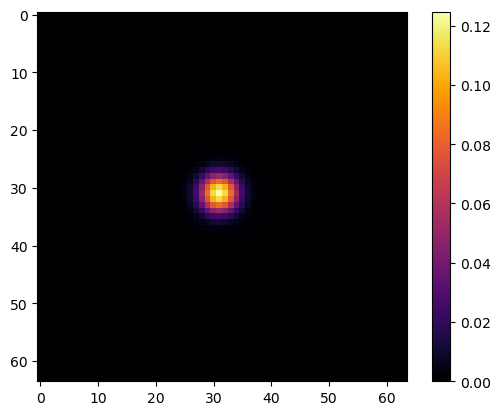

PyObject <matplotlib.colorbar.Colorbar object at 0x1a3d4f640>

In [100]:
conc0 = fill!(conc0, 0)

###################
#Gauss PROFILE:
###################

global sig =L*0.05;
global cx = 0.5*L;
global cy = 0.5*L;

for i =1:L
    for j =1:L
        conc0[i,j] =  1/(sqrt(2 * pi )*sig) * exp( -(i-cx)^2/sig^2 -(j-cy)^2/sig^2 )
    end
end

#################

conc = copy( real.(conc0) )

imshow(conc, cmap ="inferno")
colorbar()

In [101]:
conc_tr = fft(conc)

for counter = 0:n_time_steps
    
    conc_tr_new  = diff_step( conc_tr )
    conc_tr = copy(conc_tr_new)
    
    if mod(counter, time_gap) == 0 
        print( round(counter/n_time_steps, digits = 3) , ", ")
        
        conc_save = real.( ifft( conc_tr_new) )
        
        conc_time[trunc(Int,counter/time_gap)+1] = copy(conc_save)
        
        if any(isnan.(conc_save))
            print("NaNaNaN BATMAN");
            break
        end
    end
end

0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 

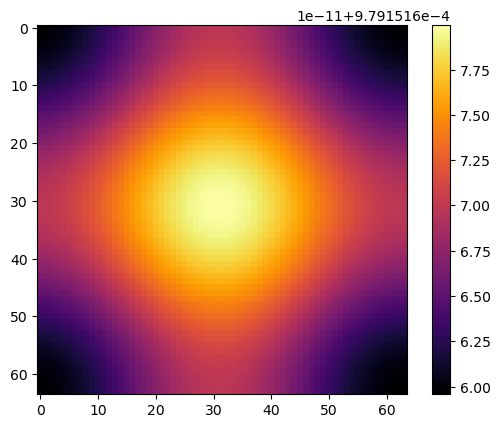

PyObject <matplotlib.colorbar.Colorbar object at 0x1a45bbd30>

In [111]:
time_display = 6
#time_display = 5

imshow( conc_time[time_display], cmap ="inferno")
colorbar()

### Active turbulence

In [115]:
# Numerical params
global L=Int(128);    # number of elements in row/column
 
global A = 100000;     # activity
global R = 1.;          # viscosity ratio
global S = 1.;          # 1. = conractile, -1 = extensile

In [116]:
# SAVING PARAMS.

global T=Int(100);       # integration time
global dt=0.001;         # timestep

global n_saving = 100;    # number of frames to be saved
global n_time_steps = Int(T/dt);
global time_gap = Int(n_time_steps/n_saving);


#CHANGE THIS PATH TO SAVE IN ANOTHER FOLDER
global fold_out = "L_$L"*"_A_$A/";

#CREATING THE FOLDER, IF IT DOESN'T EXIST
try
    mkpath(fold_out);
catch   
end


#SAVE THE PARAMETERS YOU HAVE CHOSEN.
par_names = "A,  R, S, L, T, dt, time_gap \n";
num_params = 7

par_vals = Array{Float64, 1}(undef, num_params)
par_vals = [ A,  R, S, L, T, dt, time_gap ];

open(fold_out*"params.txt", "w") do file
    write(file, par_names)
    
    for k = 1:num_params
        write(file, string(par_vals[k]) )
        write(file, ", ")
    end
    
end

In [117]:
#DEFINING THE OPERATORS YOU WILL USE IN THE FOURIER SPACE
global kx = reshape(fftfreq(L, 2π*L), (L, 1, 1));
global ky = reshape(fftfreq(L, 2π*L), (1, L, 1));

global kxy = @. kx .* ky ;

global k2 = @. kx^2 + ky^2;
global kx2_ky2 = @. kx^2 - ky^2;
global ky2_kx2 = @. ky^2 - kx^2;
global k4 = @. kx^4 + ky^4 .+ 2 .* kx^2 .* ky^2 ;

#REGULARIZING K4, THAT ENTERS IN AN INVERSION!
k_small = copy(k4);
k_small = fill!(k_small, 0)
k_small[1] = 0.0000000000001

global k4_im = k4 + im * k_small;


#PREPARING THE DE-ALIASING OPERATOR
kmax = maximum(kx)*2/ 3;
ind_x_alias = reshape( abs.(kx) .> kmax, L );
ind_y_alias = reshape( abs.(ky) .> kmax, L) ;

dealias = copy(kxy)
dealias = fill!(dealias, 1.)
dealias[ind_x_alias,:] .= 0.;
dealias[:, ind_y_alias] .= 0.;

In [118]:
# PREPARING SOME ARRAYS, SOME OF THEM WILL BE USED FOR SAVING THE ITERATIONS OVER TIME, 
# SOME JUST FOR STORAGE IN THE FUNCTIONS. I DON'T DEFINE THEM INSIDE FUNCTIONS NOT TO ALLOCATE
# TOO MUCH MEMORY, BUT MAYBE IN JULIA THIS IS NOT A PROBLEM. THERE ARE SOME PRO TIPS ON THE INTERNET, IF YOU 

global theta_time = Array{Array}(undef,n_saving+1)
global Ux_time = Array{Array}(undef,n_saving+1)
global Uy_time = Array{Array}(undef,n_saving+1)

for n_sav = 1:n_saving+1
    theta_time[n_sav] = Array{Complex{Float64}}(undef,L,L)
end

global theta = Array{Complex{Float64}}(undef,L,L);


#VARIABLES FOR THE TIME LOOP
global theta_new = copy(theta);
global theta_tr_new = copy(theta);
global psi_tr_new = copy(theta);


global theta_out = copy(theta);

# PREPARE A STATIONARY TURBULENT FIELD

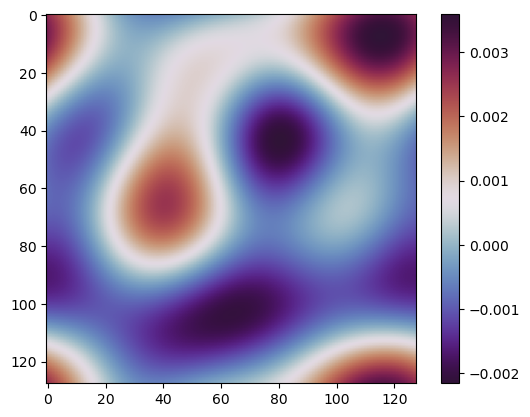

PyObject <matplotlib.colorbar.Colorbar object at 0x1a46a3f40>

In [119]:
#RANDOM INITIAL PERTURBATION OF THE THETA = 0 STATE

ranAmpli = 2 .* ( rand(25) .-0.5 ) .* pi./5000;

theta = fill!(theta, 0)

for i =1:L
    for j =1:L
        theta[i,j] =  ranAmpli[1] .* sin( 2π /L *i  ) .+ ranAmpli[2] .* cos( 2π /L *i  ) +
                      + ranAmpli[3] .* sin( 2π /L *j  ) .+ ranAmpli[4] .* cos( 2π /L *j )+
                      + ranAmpli[5] .* sin( 2π /L *(i+j)  ) .+ ranAmpli[6] .* cos( 2π /L *(i+j) )+ 
                      + ranAmpli[7] .* sin( 2π /L *(i-j)  ) .+ ranAmpli[8] .* cos( 2π /L *(i-j) )+
                      + ranAmpli[9] .* sin( 2π /L *2*i  ) .+ ranAmpli[10] .* cos( 2π /L *2*i  ) +
                      + ranAmpli[11] .* sin( 2π /L *2*j  ) .+ ranAmpli[12] .* cos( 2π /L *2*j )+
                      + ranAmpli[13] .* sin( 2π /L *(2*i+j)  ) .+ ranAmpli[14] .* cos( 2π /L *(2*i+j) )+ 
                      + ranAmpli[15] .* sin( 2π /L *(i+2*j)  ) .+ ranAmpli[16] .* cos( 2π /L *(i+2*j) );
    end
end

theta = real.(theta)

imshow(theta, cmap ="twilight_shifted")
colorbar()

In [120]:
# ALTERNATIVE: LOADING THE LAST THETA OF A PREVIOUS SIMULATION TO PROCEED WITH THE SIMULATION.

# fold_theta = "FOLDER_NAME"
# theta = reshape( readdlm("results/julia/L_512_A_1000000/last_theta_101.txt"), (L,L) )

# TAKE A LOOK AT THE LOADED FIELD
# imshow(theta, cmap = "twilight_shifted")
# colorbar()

In [121]:
# LOOP IN TIME, EACH TIME INVOKING THE FUNCTION TURBU STEP TO PERFORM AN EULER STEP

for counter = 0:n_time_steps
    
    theta_new, theta_tr_new, psi_tr_new  = turbu_step( theta, A, R, S )
    theta = copy(theta_new)
    
    if mod(counter, time_gap) == 0 
        print( round(counter/n_time_steps, digits = 3) , ", ")
        
        theta_time[trunc(Int,counter/time_gap)+1] = copy(theta)
        Ux_time[trunc(Int,counter/time_gap)+1] = real.( ifft( im * ky .* psi_tr_new) )
        Uy_time[trunc(Int,counter/time_gap)+1] = real.( ifft( -im * kx .* psi_tr_new) )
        
        if any(isnan.(theta))
            print("NaNaNaN BATMAN");
            break
        end
    end
end

0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4, 0.41, 0.42, 0.43, 

LoadError: InterruptException:

In [122]:
time_display = n_saving

imshow( theta_time[n_saving], cmap ="twilight_shifted")
colorbar()

LoadError: PyError ($(Expr(:escape, :(ccall(#= /Users/admin/.julia/packages/PyCall/1gn3u/src/pyfncall.jl:43 =# @pysym(:PyObject_Call), PyPtr, (PyPtr, PyPtr, PyPtr), o, pyargsptr, kw))))) <class 'TypeError'>
TypeError('Image data of dtype complex128 cannot be converted to float')
  File "/Users/admin/.julia/conda/3/x86_64/lib/python3.10/site-packages/matplotlib/pyplot.py", line 2695, in imshow
    __ret = gca().imshow(
  File "/Users/admin/.julia/conda/3/x86_64/lib/python3.10/site-packages/matplotlib/__init__.py", line 1446, in inner
    return func(ax, *map(sanitize_sequence, args), **kwargs)
  File "/Users/admin/.julia/conda/3/x86_64/lib/python3.10/site-packages/matplotlib/axes/_axes.py", line 5663, in imshow
    im.set_data(X)
  File "/Users/admin/.julia/conda/3/x86_64/lib/python3.10/site-packages/matplotlib/image.py", line 701, in set_data
    raise TypeError("Image data of dtype {} cannot be converted to "


In [123]:
imshow(real.(Ux_time[time_display]), cmap ="inferno")
colorbar()

LoadError: UndefRefError: access to undefined reference

In [124]:
imshow(real.(Uy_time[end]), cmap ="inferno")
colorbar()

LoadError: UndefRefError: access to undefined reference

In [125]:
#SAVE THE RESULTS, TO ANALYZE THEM IN DEPTH WITH PYTHON

try
    mkdir(fold_out*"theta");
    mkdir(fold_out*"U/");
catch   
end

for i = 1:n_saving+1
    file_title = fold_out*"U/Ux_$i.txt";
    writedlm(file_title,real.(Ux_time[i]));

    file_title = fold_out*"U/Uy_$i.txt";
    writedlm(file_title,real.(Uy_time[i]));

    file_title = fold_out*"theta/theta_$i.txt";
    writedlm(file_title,real.(theta_time[i]));
end

file_title = fold_out*"last_theta_$(n_saving+1).txt";
writedlm(file_title,real.(theta_time[end]));

LoadError: UndefRefError: access to undefined reference